# Vol 18 — Theory-Guided Surrogates & Greeks

**問い:** 高速な近似器は、価格だけでなくGreeksと無裁定条件をどこまで守れるか。

> **核心** — 複雑なモデルは必ず単純baselineとhard checkに並べる。<br>
> **直感** — 平均誤差だけでは、尾部・裁定・cash-flow破綻を隠せる。<br>
> **実務** — 再現可能なartifactと明示的な失敗条件をmodel risk管理の単位にする。

## モデルladderと責務

解析BSをbaselineに、price-only MLP、direct Greek head、Differential ML、time-value residualを同じsplitで比較する。Heston/COSとMC teacherはSE・95% CI付きで扱い、soft penaltyとは別にhullkitのhard reportを正本とする。

## Artifact契約とdata policy

このnotebookはcommitted JSON/NPZだけを読み、学習・download・GPU検出を行わない。

In [1]:
from pathlib import Path
import hashlib, json
import numpy as np
import matplotlib.pyplot as plt

reference = Path('reference')
manifest = json.loads((reference / 'pricing_metrics.json').read_text(encoding='utf-8'))
artifact = reference / 'pricing_slices.npz'
digest = hashlib.sha256(artifact.read_bytes()).hexdigest()
assert manifest['schema_version'] == 1 and manifest['volume'] == 18
assert manifest['data_policy'] == 'synthetic-offline'
assert manifest['companions'][artifact.name] == digest
archive = np.load(artifact, allow_pickle=False)
schema = manifest['companion_schemas'][artifact.name]
assert set(schema) == set(archive.files)
for name in archive.files:
    assert schema[name]['shape'] == list(archive[name].shape)
    assert schema[name]['dtype'] == str(archive[name].dtype)
    assert schema[name]['unit']
artifact_data = {name: archive[name] for name in archive.files}
archive.close()
data = dict(artifact_data)
print(f"schema={manifest['schema_version']} volume={manifest['volume']} digest={digest[:16]} arrays={len(artifact_data)}")

schema=1 volume=18 digest=a36059022f5c68d2 arrays=13


## 指標の要約

指標は同じsynthetic fixture・単位・seedで比較する。

In [2]:
for key, value in manifest['metrics'].items():
    print(f'{key}: {value}')

break_even_batch: None
delta_mae: 0.0017494819891811248
dml_improved_a_greek_without_price_degradation: True
hard_violation_rate: 0.0
heston_bsm_residual_mae: 0.0006117290429284944
heston_raw_price_mae: 0.012620526620790065
price_mae_normalized: 0.0005593846268355811
soft_penalty_improved_hard_checks: False
split_overlap_count: 0
teacher_ci_coverage_20_seeds: 0.9
teacher_ci_coverage_20_seeds_by_estimand: {'delta': 1.0, 'price': 0.9, 'vega': 0.9}
teacher_se_ratio_4x_paths: 0.5036523091029843
teacher_se_ratio_4x_paths_by_estimand: {'delta': 0.5000675502958665, 'price': 0.5036523091029843, 'vega': 0.5018588397313818}


## Acceptance scope

この判定はintegrationと再現性だけを対象とし、市場適合・予測力・production readinessを承認しない。

In [3]:
assert manifest['acceptance']['scope'] == 'integration_and_reproducibility'
assert manifest['acceptance']['model_performance_approved'] is False
assert manifest['acceptance']['passed'] is True
for check in manifest['acceptance']['checks']:
    print(('PASS' if check['passed'] else 'FAIL'), check['name'], check['observed'], check['criterion'])

PASS split_overlap_count 0 == 0
PASS price_mae_normalized 0.0005593846268355811 < 0.001
PASS delta_mae 0.0017494819891811248 < 0.002
PASS hard_check_set 8 exact documented 8-check set
PASS hard_check_violations 0 == 0
PASS residual_baseline 0.0006117290429284944 < raw-price MAE
PASS mc_ci_coverage 0.9 each estimand in [0.80, 1.00]
PASS mc_standard_error_scaling 0.5036523091029843 each 4x-path ratio in [0.40, 0.60]


## 価格誤差サーフェス

単一のaggregate scoreではなく、構造別・時間別・stress別に読む。

/home/kazumasa/projects/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20385 (\N{CJK UNIFIED IDEOGRAPH-4FA1}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kazumasa/projects/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26684 (\N{CJK UNIFIED IDEOGRAPH-683C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kazumasa/projects/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 35492 (\N{CJK UNIFIED IDEOGRAPH-8AA4}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kazumasa/projects/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24046 (\N{CJK UNIFIED IDEOGRAPH-5DEE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kazumasa/projects/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarni

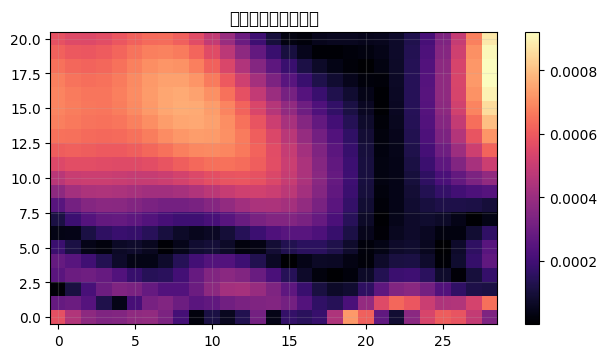

In [4]:
fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.set_title("価格誤差サーフェス")
im = ax.imshow(data["price_error"], aspect="auto", origin="lower", cmap="magma")
fig.colorbar(im, ax=ax)
ax.grid(alpha=.2)
plt.show()

## Delta誤差のmoneyness依存

単一のaggregate scoreではなく、構造別・時間別・stress別に読む。

/home/kazumasa/projects/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kazumasa/projects/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20381 (\N{CJK UNIFIED IDEOGRAPH-4F9D}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kazumasa/projects/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 23384 (\N{CJK UNIFIED IDEOGRAPH-5B58}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


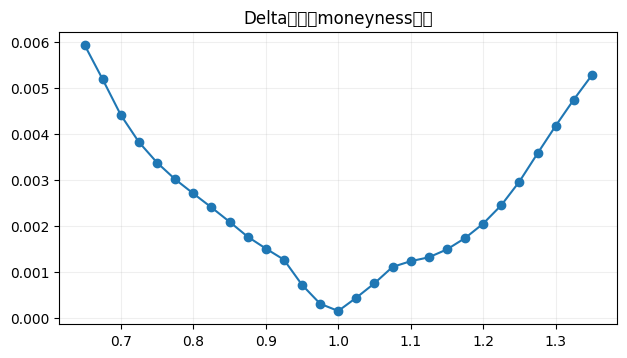

In [5]:
fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.set_title("Delta誤差のmoneyness依存")
ax.plot(data["moneyness"], data["delta_error"], marker="o")
ax.grid(alpha=.2)
plt.show()

## soft loss前後のhard violation

単一のaggregate scoreではなく、構造別・時間別・stress別に読む。

/home/kazumasa/projects/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21069 (\N{CJK UNIFIED IDEOGRAPH-524D}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kazumasa/projects/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24460 (\N{CJK UNIFIED IDEOGRAPH-5F8C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kazumasa/projects/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


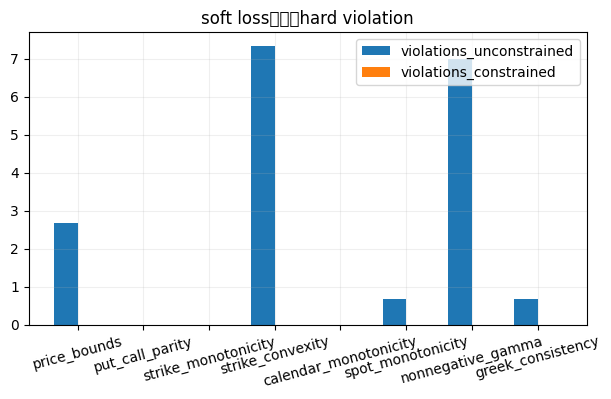

In [6]:
fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.set_title("soft loss前後のhard violation")
x = np.arange(len(data["check_names"]))
ax.bar(x - .18, data["violations_unconstrained"], width=.36, label="violations_unconstrained")
ax.bar(x + .18, data["violations_constrained"], width=.36, label="violations_constrained")
ax.set_xticks(x, data["check_names"], rotation=15)
ax.legend()
ax.grid(alpha=.2)
plt.show()

## CPU batch latency

単一のaggregate scoreではなく、構造別・時間別・stress別に読む。

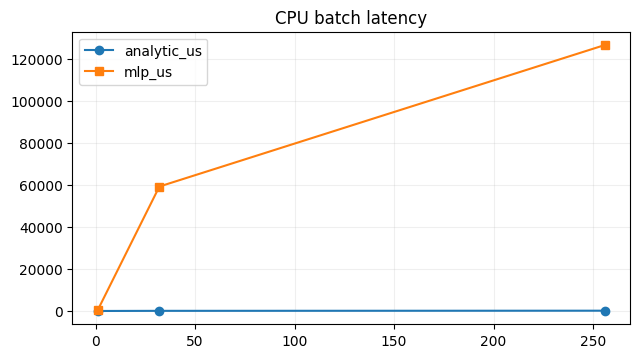

In [7]:
fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.set_title("CPU batch latency")
ax.plot(data["batch_size"], data["analytic_us"], marker="o", label="analytic_us")
ax.plot(data["batch_size"], data["mlp_us"], marker="s", label="mlp_us")
ax.legend()
ax.grid(alpha=.2)
plt.show()

## Gate判定

artifact fingerprint、finite values、主要identityを機械的に確認する。

In [8]:
assert all(np.all(np.isfinite(values)) for values in artifact_data.values() if values.dtype.kind in 'fiu')
assert manifest['companions'][artifact.name] == hashlib.sha256(artifact.read_bytes()).hexdigest()
assert set(manifest['companion_schemas'][artifact.name]) == set(artifact_data)
print('PASS: fingerprint, schema, units, and finite-value checks')

PASS: fingerprint, schema, units, and finite-value checks


## 限界とnegative results

本巻の数値はsynthetic fixtureによる教育・integration検証であり、市場予測力、収益性、実運用較正を示さない。複雑モデルがbaselineに勝たない場合もnegative resultとして保持する。

## Research track

未査読preprintや重いモデルはoptional profileに隔離し、core artifact・notebook・book・portalの再構築を妨げない。

## 参考文献

Black & Scholes (1973); Huge & Savine, Differential Machine Learning (2020); Dugas et al. (2009).

## まとめ

価格・統計誤差だけでなく、hard constraints、下流risk、計算量、data/model limitationsを同じ成果物に固定した。